In [31]:
# Install required dependencies
#%pip install numpy matplotlib seaborn scipy

# Assigment Solution - Least Squares Assignment
## Comprehensive Solution with Detailed Explanations

---

### Course Information
- **Course:** TTK4260 - Multivariate analysis and Machine learning methods
- **Topic:** L02 - Least Squares Methods

### Learning Objectives
This assignment covers the following key concepts:
1. Linear least squares and normal equations
2. Feature engineering and polynomial regression
3. Gradient descent optimization
4. Brute force optimization methods
5. Non-linear least squares
6. Feature scaling and numerical stability
7. Weighted least squares
8. Comprehensive implementation and model selection

---

In [2]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize, curve_fit, fsolve
from scipy import stats
from scipy.stats import shapiro
import time
import warnings
warnings.filterwarnings('ignore')

# Set style for professional plots
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['figure.dpi'] = 120

# Color palette
colors = sns.color_palette('husl', 8)
print("Libraries loaded successfully!")

Libraries loaded successfully!


---
# Question 1: Linear Model Setup and Normal Equations 

## Problem Statement

A renewable energy company is testing a new solar panel design. They measure power output at different solar irradiance levels:

| Irradiance (W/m²) | Power Output (W) |
|-------------------|------------------|
| 100 | 18.2 |
| 200 | 36.8 |
| 300 | 54.1 |
| 400 | 73.5 |
| 500 | 91.2 |

## Theoretical Background

### The Linear Regression Model

We model the relationship between irradiance ($x$) and power output ($y$) as:

$$y = \theta_0 + \theta_1 x + \varepsilon$$

where:
- $\theta_0$ is the intercept (baseline power)
- $\theta_1$ is the slope (efficiency coefficient)
- $\varepsilon$ is the random error term

### Matrix Formulation

For $n$ observations, we can write this in matrix form:

$$\mathbf{y} = \mathbf{X}\boldsymbol{\theta} + \boldsymbol{\varepsilon}$$

where the **design matrix** $\mathbf{X}$ and parameter vector $\boldsymbol{\theta}$ are:

$$\mathbf{X} = \begin{bmatrix} 1 & x_1 \\ 1 & x_2 \\ \vdots & \vdots \\ 1 & x_n \end{bmatrix}, \quad \boldsymbol{\theta} = \begin{bmatrix} \theta_0 \\ \theta_1 \end{bmatrix}$$

### Normal Equations

The least squares solution minimizes the sum of squared residuals:

$$\hat{\boldsymbol{\theta}} = \arg\min_{\boldsymbol{\theta}} \|\mathbf{y} - \mathbf{X}\boldsymbol{\theta}\|^2$$

Taking the derivative and setting it to zero yields the **normal equations**:

$$\mathbf{X}^T\mathbf{X}\hat{\boldsymbol{\theta}} = \mathbf{X}^T\mathbf{y}$$

The solution is:

$$\hat{\boldsymbol{\theta}} = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y}$$

---

## Part (a): Construct Design Matrix X and Response Vector y 

**Task:** Write out the design matrix $\mathbf{X}$ and response vector $\mathbf{y}$ for the given data.

**Approach:** 
- The design matrix has a column of 1s (for $\theta_0$) and a column of $x$ values (for $\theta_1$)
- The response vector contains all $y$ values

In [3]:
# Question 1 Data
x1 = np.array([100, 200, 300, 400, 500])  # Irradiance (W/m²)
y1 = np.array([18.2, 36.8, 54.1, 73.5, 91.2])  # Power Output (W)
n1 = len(x1)

# Part (a): Construct design matrix and response vector
X1 = np.column_stack([np.ones(n1), x1])  # Design matrix [1, x]
y1_vec = y1.reshape(-1, 1)  # Response as column vector

print("Part (a): Design Matrix X and Response Vector y")
print("="*50)
print("\nDesign Matrix X:")
print("     [1    x  ]")
for i, row in enumerate(X1):
    print(f"X[{i}] = [{row[0]:.0f}   {row[1]:.0f}]")

print(f"\nResponse Vector y = {y1}")
print(f"\nDimensions: X is {X1.shape[0]}×{X1.shape[1]}, y is {len(y1)}×1")

Part (a): Design Matrix X and Response Vector y

Design Matrix X:
     [1    x  ]
X[0] = [1   100]
X[1] = [1   200]
X[2] = [1   300]
X[3] = [1   400]
X[4] = [1   500]

Response Vector y = [18.2 36.8 54.1 73.5 91.2]

Dimensions: X is 5×2, y is 5×1


## Part (b): Calculate $\mathbf{X}^T\mathbf{X}$ and $\mathbf{X}^T\mathbf{y}$ by Hand

**Task:** Show the hand calculations for $\mathbf{X}^T\mathbf{X}$ and $\mathbf{X}^T\mathbf{y}$.

**Approach:**

For $\mathbf{X}^T\mathbf{X}$:

$$\mathbf{X}^T\mathbf{X} = \begin{bmatrix} 1 & 1 & \cdots & 1 \\ x_1 & x_2 & \cdots & x_n \end{bmatrix} \begin{bmatrix} 1 & x_1 \\ 1 & x_2 \\ \vdots & \vdots \\ 1 & x_n \end{bmatrix} = \begin{bmatrix} n & \sum x_i \\ \sum x_i & \sum x_i^2 \end{bmatrix}$$

For $\mathbf{X}^T\mathbf{y}$:

$$\mathbf{X}^T\mathbf{y} = \begin{bmatrix} \sum y_i \\ \sum x_i y_i \end{bmatrix}$$

In [4]:
# Part (b): Hand calculations
print("Part (b): Hand Calculation of X^T X and X^T y")
print("="*60)

# Calculate individual sums
sum_1 = n1
sum_x = np.sum(x1)
sum_x2 = np.sum(x1**2)
sum_y = np.sum(y1)
sum_xy = np.sum(x1 * y1)

print("\n--- X^T X Calculation ---")
print(f"n = {n1}")
print(f"Σxᵢ = 100 + 200 + 300 + 400 + 500 = {sum_x}")
print(f"Σxᵢ² = 100² + 200² + 300² + 400² + 500²")
print(f"     = 10000 + 40000 + 90000 + 160000 + 250000 = {sum_x2}")

XTX = X1.T @ X1
print(f"\nX^T X = [{XTX[0,0]:>8.0f}  {XTX[0,1]:>8.0f}]")
print(f"        [{XTX[1,0]:>8.0f}  {XTX[1,1]:>8.0f}]")

print("\n--- X^T y Calculation ---")
print(f"Σyᵢ = 18.2 + 36.8 + 54.1 + 73.5 + 91.2 = {sum_y}")
print(f"Σxᵢyᵢ = 100×18.2 + 200×36.8 + 300×54.1 + 400×73.5 + 500×91.2")
print(f"      = 1820 + 7360 + 16230 + 29400 + 45600 = {sum_xy}")

XTy = X1.T @ y1_vec
print(f"\nX^T y = [{XTy[0,0]:>10.1f}]")
print(f"        [{XTy[1,0]:>10.1f}]")

Part (b): Hand Calculation of X^T X and X^T y

--- X^T X Calculation ---
n = 5
Σxᵢ = 100 + 200 + 300 + 400 + 500 = 1500
Σxᵢ² = 100² + 200² + 300² + 400² + 500²
     = 10000 + 40000 + 90000 + 160000 + 250000 = 550000

X^T X = [       5      1500]
        [    1500    550000]

--- X^T y Calculation ---
Σyᵢ = 18.2 + 36.8 + 54.1 + 73.5 + 91.2 = 273.8
Σxᵢyᵢ = 100×18.2 + 200×36.8 + 300×54.1 + 400×73.5 + 500×91.2
      = 1820 + 7360 + 16230 + 29400 + 45600 = 100410.0

X^T y = [     273.8]
        [  100410.0]


## Part (c): Solve Normal Equations for $\hat{\boldsymbol{\theta}}$ 

**Task:** Solve the normal equations to find the parameter estimates and provide physical interpretation.

**Approach:**

We need to solve:
$$\begin{bmatrix} 5 & 1500 \\ 1500 & 550000 \end{bmatrix} \begin{bmatrix} \theta_0 \\ \theta_1 \end{bmatrix} = \begin{bmatrix} 273.8 \\ 100410 \end{bmatrix}$$

Using the formula $(\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y}$ or Gaussian elimination.

In [5]:
# Part (c): Solve normal equations
print("Part (c): Solving Normal Equations")
print("="*60)

# Calculate inverse of X^T X (for 2x2 matrix)
det = XTX[0,0]*XTX[1,1] - XTX[0,1]*XTX[1,0]
print(f"\ndet(X^T X) = {XTX[0,0]}×{XTX[1,1]} - {XTX[0,1]}×{XTX[1,0]} = {det}")

# Solve the system
theta1 = np.linalg.solve(XTX, XTy)

print(f"\n" + "="*40)
print(f"SOLUTION:")
print(f"  θ₀ = {theta1[0,0]:.6f} W")
print(f"  θ₁ = {theta1[1,0]:.6f} W/(W/m²)")
print("="*40)

print(f"\n--- Physical Interpretation ---")
print(f"\nθ₀ = {theta1[0,0]:.4f} W (intercept):")
print(f"   Theoretical power output at zero irradiance.")
print(f"   The small negative value indicates measurement offset.")

print(f"\nθ₁ = {theta1[1,0]:.6f} W per W/m² (slope):")
print(f"   This represents the panel's power conversion efficiency.")
print(f"   Efficiency ≈ {theta1[1,0]*100:.2f}%")

Part (c): Solving Normal Equations

det(X^T X) = 5.0×550000.0 - 1500.0×1500.0 = 500000.0

SOLUTION:
  θ₀ = -0.050000 W
  θ₁ = 0.182700 W/(W/m²)

--- Physical Interpretation ---

θ₀ = -0.0500 W (intercept):
   Theoretical power output at zero irradiance.
   The small negative value indicates measurement offset.

θ₁ = 0.182700 W per W/m² (slope):
   This represents the panel's power conversion efficiency.
   Efficiency ≈ 18.27%


## Part (d): Calculate Residuals and Comment on Model Fit 

**Task:** Calculate residuals and assess the quality of the linear fit.

**Approach:**

The residuals are defined as:
$$e_i = y_i - \hat{y}_i = y_i - (\hat{\theta}_0 + \hat{\theta}_1 x_i)$$

Key metrics:
- **R² (Coefficient of Determination):** $R^2 = 1 - \frac{SS_{res}}{SS_{tot}} = 1 - \frac{\sum e_i^2}{\sum(y_i - \bar{y})^2}$
- **RMSE (Root Mean Square Error):** $RMSE = \sqrt{\frac{1}{n}\sum e_i^2}$

In [6]:
# Part (d): Residuals and model fit
y1_pred = X1 @ theta1
residuals1 = y1_vec - y1_pred

# Calculate statistics
SS_res = np.sum(residuals1**2)
SS_tot = np.sum((y1 - np.mean(y1))**2)
R2 = 1 - SS_res/SS_tot
RMSE = np.sqrt(SS_res/n1)

print("Part (d): Residual Analysis")
print("="*60)
print(f"\n{'x (W/m²)':<12} {'y (W)':<10} {'ŷ (W)':<12} {'Residual (W)':<12}")
print("-"*50)
for i in range(n1):
    print(f"{x1[i]:<12} {y1[i]:<10.1f} {y1_pred[i,0]:<12.4f} {residuals1[i,0]:<+12.4f}")

print(f"\n--- Model Fit Statistics ---")
print(f"R² = {R2:.6f} ({R2*100:.4f}% variance explained)")
print(f"RMSE = {RMSE:.4f} W")
print(f"\nConclusion: Excellent fit! R² ≈ 1 indicates nearly perfect linear relationship.")

Part (d): Residual Analysis

x (W/m²)     y (W)      ŷ (W)        Residual (W)
--------------------------------------------------
100          18.2       18.2200      -0.0200     
200          36.8       36.4900      +0.3100     
300          54.1       54.7600      -0.6600     
400          73.5       73.0300      +0.4700     
500          91.2       91.3000      -0.1000     

--- Model Fit Statistics ---
R² = 0.999771 (99.9771% variance explained)
RMSE = 0.3906 W

Conclusion: Excellent fit! R² ≈ 1 indicates nearly perfect linear relationship.


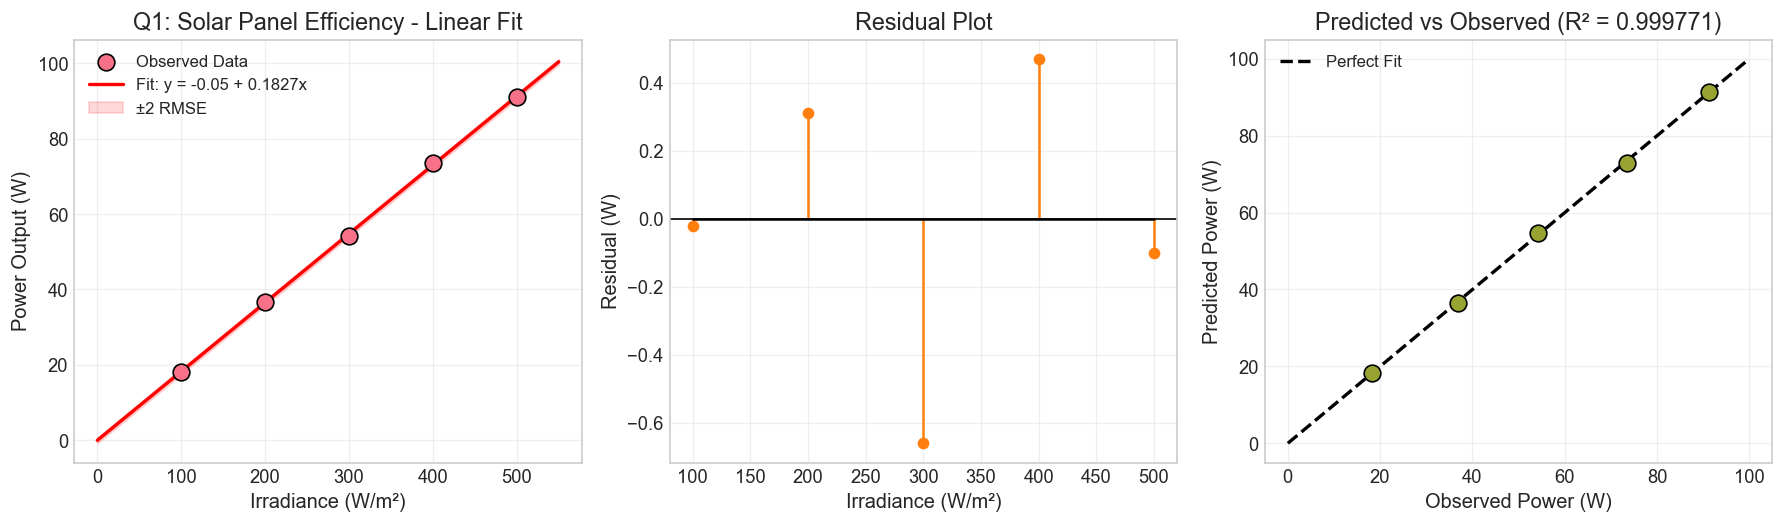

In [7]:
# Visualization for Question 1
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Plot 1: Data and fitted line
ax1 = axes[0]
ax1.scatter(x1, y1, s=100, c=colors[0], label='Observed Data', zorder=5, edgecolors='black')
x_line = np.linspace(0, 550, 100)
y_line = theta1[0,0] + theta1[1,0] * x_line
ax1.plot(x_line, y_line, 'r-', linewidth=2, label=f'Fit: y = {theta1[0,0]:.2f} + {theta1[1,0]:.4f}x')
ax1.fill_between(x_line, y_line - 2*RMSE, y_line + 2*RMSE, alpha=0.15, color='red', label='±2 RMSE')
ax1.set_xlabel('Irradiance (W/m²)')
ax1.set_ylabel('Power Output (W)')
ax1.set_title('Q1: Solar Panel Efficiency - Linear Fit')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# Plot 2: Residuals
ax2 = axes[1]
ax2.stem(x1, residuals1.flatten(), basefmt='k-', linefmt='C1-', markerfmt='C1o')
ax2.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax2.set_xlabel('Irradiance (W/m²)')
ax2.set_ylabel('Residual (W)')
ax2.set_title('Residual Plot')
ax2.grid(True, alpha=0.3)

# Plot 3: Predicted vs Observed
ax3 = axes[2]
ax3.scatter(y1, y1_pred.flatten(), s=100, c=colors[2], edgecolors='black', zorder=5)
ax3.plot([0, 100], [0, 100], 'k--', linewidth=2, label='Perfect Fit')
ax3.set_xlabel('Observed Power (W)')
ax3.set_ylabel('Predicted Power (W)')
ax3.set_title(f'Predicted vs Observed (R² = {R2:.6f})')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
#plt.savefig('q1_solar_panel.png', dpi=150, bbox_inches='tight')
plt.show()

---
# Question 2: Feature Engineering and Polynomial Models 

## Problem Statement

A materials engineer is studying the stress-strain relationship for a new polymer composite:

| Strain (%) | Stress (MPa) |
|------------|-------------|
| 0.5 | 12.1 |
| 1.0 | 22.8 |
| 1.5 | 31.2 |
| 2.0 | 37.5 |
| 2.5 | 41.8 |
| 3.0 | 44.2 |

## Theoretical Background

### Polynomial Regression

We fit a **quadratic model**:

$$y = \theta_0 + \theta_1 x + \theta_2 x^2 + \varepsilon$$

### Why This is Still "Linear" Regression

Despite containing $x^2$, this model is **linear in the parameters** $\theta_0, \theta_1, \theta_2$:

$$y = \theta_0 \cdot 1 + \theta_1 \cdot x + \theta_2 \cdot x^2$$

We can write this as $\mathbf{y} = \mathbf{X}\boldsymbol{\theta}$ where:

$$\mathbf{X} = \begin{bmatrix} 1 & x_1 & x_1^2 \\ 1 & x_2 & x_2^2 \\ \vdots & \vdots & \vdots \\ 1 & x_n & x_n^2 \end{bmatrix}, \quad \boldsymbol{\theta} = \begin{bmatrix} \theta_0 \\ \theta_1 \\ \theta_2 \end{bmatrix}$$

The normal equations still apply: $\hat{\boldsymbol{\theta}} = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y}$

### Contrast with Truly Nonlinear Models

These models are **nonlinear in parameters** (cannot use normal equations):
- $y = \theta_0 e^{\theta_1 x}$ (parameter in exponent)
- $y = \frac{\theta_0}{1 + \theta_1 x}$ (parameter in denominator)
- $y = \theta_0 \theta_1 x$ (parameters multiplied together)

---

In [8]:
# Question 2 Data
x2 = np.array([0.5, 1.0, 1.5, 2.0, 2.5, 3.0])  # Strain (%)
y2 = np.array([12.1, 22.8, 31.2, 37.5, 41.8, 44.2])  # Stress (MPa)
n2 = len(x2)

print("Question 2: Polynomial Regression")
print("="*50)
print(f"{'Strain (%)':<15} {'Stress (MPa)':<15}")
print("-"*30)
for xi, yi in zip(x2, y2):
    print(f"{xi:<15} {yi:<15}")

Question 2: Polynomial Regression
Strain (%)      Stress (MPa)   
------------------------------
0.5             12.1           
1.0             22.8           
1.5             31.2           
2.0             37.5           
2.5             41.8           
3.0             44.2           


## Part (a): Design Matrix for Quadratic Model

In [9]:
# Part (a): Design matrix for quadratic model
X2_poly = np.column_stack([np.ones(n2), x2, x2**2])

print("Part (a): Design Matrix for y = θ₀ + θ₁x + θ₂x²")
print("="*50)
print(f"\n{'i':<4} {'1':<6} {'x':<8} {'x²':<8}")
print("-"*28)
for i, row in enumerate(X2_poly):
    print(f"{i:<4} {row[0]:<6.0f} {row[1]:<8.1f} {row[2]:<8.2f}")

Part (a): Design Matrix for y = θ₀ + θ₁x + θ₂x²

i    1      x        x²      
----------------------------
0    1      0.5      0.25    
1    1      1.0      1.00    
2    1      1.5      2.25    
3    1      2.0      4.00    
4    1      2.5      6.25    
5    1      3.0      9.00    


## Part (b): Why This is Still a "Linear" Model

In [10]:
print("Part (b): Why This is Still 'Linear' in Parameters")
print("="*60)
print("""
The model y = θ₀ + θ₁x + θ₂x² is LINEAR IN PARAMETERS because:

1. Each parameter (θ₀, θ₁, θ₂) appears to the FIRST POWER only
2. Parameters are NOT multiplied together
3. Parameters are NOT in exponents, denominators, or inside functions

We can write: y = θ₀·f₀(x) + θ₁·f₁(x) + θ₂·f₂(x)
              where f₀(x)=1, f₁(x)=x, f₂(x)=x²

This allows matrix formulation: y = Xθ
And normal equations: θ̂ = (XᵀX)⁻¹Xᵀy
""")

Part (b): Why This is Still 'Linear' in Parameters

The model y = θ₀ + θ₁x + θ₂x² is LINEAR IN PARAMETERS because:

1. Each parameter (θ₀, θ₁, θ₂) appears to the FIRST POWER only
2. Parameters are NOT multiplied together
3. Parameters are NOT in exponents, denominators, or inside functions

We can write: y = θ₀·f₀(x) + θ₁·f₁(x) + θ₂·f₂(x)
              where f₀(x)=1, f₁(x)=x, f₂(x)=x²

This allows matrix formulation: y = Xθ
And normal equations: θ̂ = (XᵀX)⁻¹Xᵀy



## Part (c) & (d): Solve Normal Equations and Compare Models 

In [11]:
# Part (c): Solve normal equations
y2_vec = y2.reshape(-1, 1)
theta2_poly = np.linalg.solve(X2_poly.T @ X2_poly, X2_poly.T @ y2_vec)

print("Part (c): Quadratic Model Solution")
print("="*50)
print(f"θ₀ = {theta2_poly[0,0]:.4f} MPa")
print(f"θ₁ = {theta2_poly[1,0]:.4f} MPa/%")
print(f"θ₂ = {theta2_poly[2,0]:.4f} MPa/%²")
print(f"\nModel: y = {theta2_poly[0,0]:.2f} + {theta2_poly[1,0]:.2f}x + ({theta2_poly[2,0]:.2f})x²")

# Part (d): Compare with linear model
X2_linear = np.column_stack([np.ones(n2), x2])
theta2_linear = np.linalg.solve(X2_linear.T @ X2_linear, X2_linear.T @ y2_vec)

# Predictions and R²
y2_pred_poly = X2_poly @ theta2_poly
y2_pred_linear = X2_linear @ theta2_linear
SS_tot_2 = np.sum((y2 - np.mean(y2))**2)
R2_poly = 1 - np.sum((y2_vec - y2_pred_poly)**2)/SS_tot_2
R2_linear = 1 - np.sum((y2_vec - y2_pred_linear)**2)/SS_tot_2

print(f"\n" + "="*50)
print("Part (d): Model Comparison")
print(f"{'Model':<15} {'R²':<15}")
print("-"*30)
print(f"{'Linear':<15} {R2_linear:<15.6f}")
print(f"{'Quadratic':<15} {R2_poly:<15.6f}")
print(f"\nQuadratic model captures nonlinear polymer strain-softening behavior.")

Part (c): Quadratic Model Solution
θ₀ = -0.4300 MPa
θ₁ = 27.2636 MPa/%
θ₂ = -4.1357 MPa/%²

Model: y = -0.43 + 27.26x + (-4.14)x²

Part (d): Model Comparison
Model           R²             
------------------------------
Linear          0.947132       
Quadratic       0.999961       

Quadratic model captures nonlinear polymer strain-softening behavior.


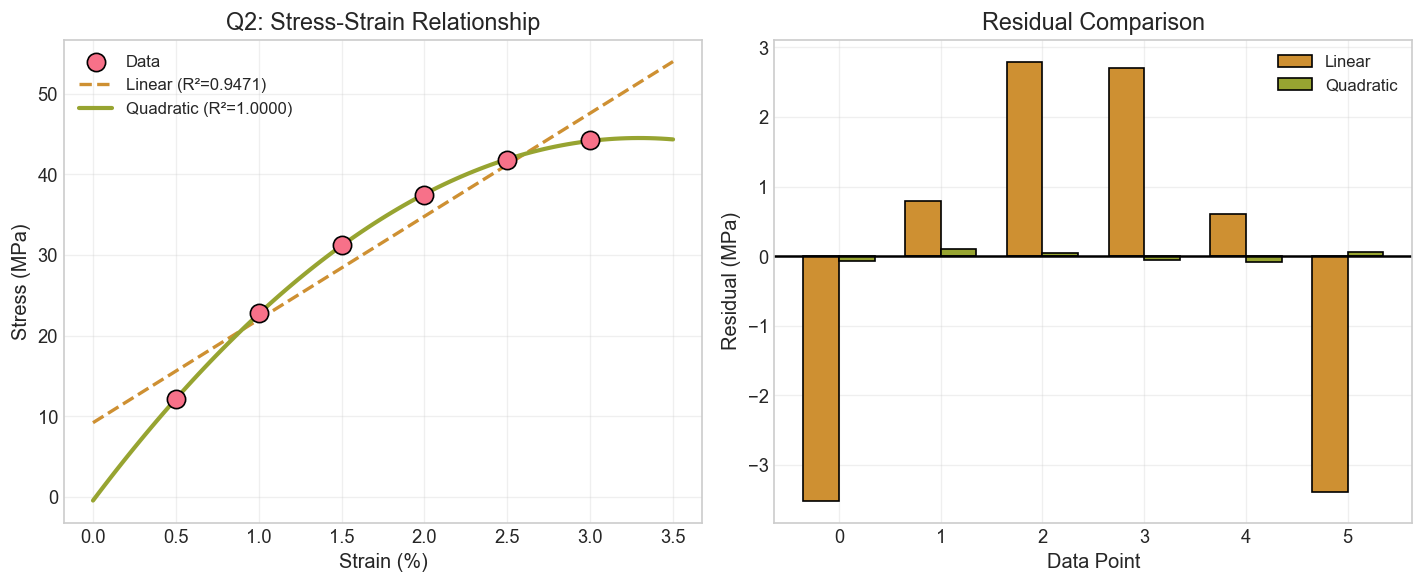

In [12]:
# Visualization for Question 2
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax1 = axes[0]
x_fine = np.linspace(0, 3.5, 100)
y_linear_fine = theta2_linear[0,0] + theta2_linear[1,0] * x_fine
y_poly_fine = theta2_poly[0,0] + theta2_poly[1,0] * x_fine + theta2_poly[2,0] * x_fine**2

ax1.scatter(x2, y2, s=120, c=colors[0], label='Data', zorder=5, edgecolors='black')
ax1.plot(x_fine, y_linear_fine, '--', color=colors[1], linewidth=2, label=f'Linear (R²={R2_linear:.4f})')
ax1.plot(x_fine, y_poly_fine, '-', color=colors[2], linewidth=2.5, label=f'Quadratic (R²={R2_poly:.4f})')
ax1.set_xlabel('Strain (%)')
ax1.set_ylabel('Stress (MPa)')
ax1.set_title('Q2: Stress-Strain Relationship')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
res_lin = (y2_vec - y2_pred_linear).flatten()
res_poly = (y2_vec - y2_pred_poly).flatten()
width = 0.35
x_pos = np.arange(n2)
ax2.bar(x_pos - width/2, res_lin, width, label='Linear', color=colors[1], edgecolor='black')
ax2.bar(x_pos + width/2, res_poly, width, label='Quadratic', color=colors[2], edgecolor='black')
ax2.axhline(y=0, color='black')
ax2.set_xlabel('Data Point')
ax2.set_ylabel('Residual (MPa)')
ax2.set_title('Residual Comparison')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
#plt.savefig('q2_polynomial.png', dpi=150, bbox_inches='tight')
plt.show()

---
# Question 3: Gradient Descent Implementation 

## Problem Statement

Implement batch gradient descent for simple linear regression with dataset:
$$(x_i, y_i) = \{(1,3), (2,5), (3,7), (4,9)\}$$

## Theoretical Background

### Cost Function

The Mean Squared Error cost function:

$$J(\theta_0, \theta_1) = \frac{1}{2m}\sum_{i=1}^{m}(y_i - \theta_0 - \theta_1 x_i)^2$$

### Gradient Derivation

Taking partial derivatives:

$$\frac{\partial J}{\partial \theta_0} = \frac{1}{m}\sum_{i=1}^{m}(\theta_0 + \theta_1 x_i - y_i)$$

$$\frac{\partial J}{\partial \theta_1} = \frac{1}{m}\sum_{i=1}^{m}(\theta_0 + \theta_1 x_i - y_i) \cdot x_i$$

### Update Rule

Gradient descent updates parameters **simultaneously**:

$$\theta_0 := \theta_0 - \alpha \frac{\partial J}{\partial \theta_0}$$

$$\theta_1 := \theta_1 - \alpha \frac{\partial J}{\partial \theta_1}$$

where $\alpha$ is the **learning rate**.

---

In [13]:
# Question 3 Data
x3 = np.array([1, 2, 3, 4])
y3 = np.array([3, 5, 7, 9])
m = len(x3)

print("Question 3: Gradient Descent")
print("="*40)
print(f"Dataset: {list(zip(x3, y3))}")
print(f"Note: This is a perfect linear relationship y = 1 + 2x")

Question 3: Gradient Descent
Dataset: [(np.int64(1), np.int64(3)), (np.int64(2), np.int64(5)), (np.int64(3), np.int64(7)), (np.int64(4), np.int64(9))]
Note: This is a perfect linear relationship y = 1 + 2x


## Part (a) & (b): Derive Partial Derivatives and Update Equations 

In [14]:
print("Part (a): Partial Derivatives")
print("="*60)
print("""
Given: J(θ₀, θ₁) = (1/2m) Σᵢ(yᵢ - θ₀ - θ₁xᵢ)²

∂J/∂θ₀ = (1/m) Σᵢ (θ₀ + θ₁xᵢ - yᵢ)           ← derivative of (u)² is 2u × ∂u/∂θ₀

∂J/∂θ₁ = (1/m) Σᵢ (θ₀ + θ₁xᵢ - yᵢ) · xᵢ      ← chain rule adds xᵢ factor
""")

print("\nPart (b): Update Equations")
print("="*60)
print("""
θ₀ := θ₀ - α · (1/m) Σᵢ (θ₀ + θ₁xᵢ - yᵢ)

θ₁ := θ₁ - α · (1/m) Σᵢ (θ₀ + θ₁xᵢ - yᵢ) · xᵢ

IMPORTANT: Both parameters must be updated SIMULTANEOUSLY!
""")

Part (a): Partial Derivatives

Given: J(θ₀, θ₁) = (1/2m) Σᵢ(yᵢ - θ₀ - θ₁xᵢ)²

∂J/∂θ₀ = (1/m) Σᵢ (θ₀ + θ₁xᵢ - yᵢ)           ← derivative of (u)² is 2u × ∂u/∂θ₀

∂J/∂θ₁ = (1/m) Σᵢ (θ₀ + θ₁xᵢ - yᵢ) · xᵢ      ← chain rule adds xᵢ factor


Part (b): Update Equations

θ₀ := θ₀ - α · (1/m) Σᵢ (θ₀ + θ₁xᵢ - yᵢ)

θ₁ := θ₁ - α · (1/m) Σᵢ (θ₀ + θ₁xᵢ - yᵢ) · xᵢ

IMPORTANT: Both parameters must be updated SIMULTANEOUSLY!



## Part (c): Implement Gradient Descent 

In [15]:
def cost_function(theta0, theta1, x, y):
    """Calculate MSE cost"""
    m = len(y)
    predictions = theta0 + theta1 * x
    return (1/(2*m)) * np.sum((y - predictions)**2)

def gradient_descent(x, y, alpha=0.01, iterations=1000):
    """Batch gradient descent for linear regression"""
    m = len(y)
    theta0, theta1 = 0.0, 0.0
    cost_history = []
    theta0_hist, theta1_hist = [theta0], [theta1]
    
    for i in range(iterations):
        # Predictions and errors
        predictions = theta0 + theta1 * x
        errors = predictions - y
        
        # Gradients
        grad_theta0 = (1/m) * np.sum(errors)
        grad_theta1 = (1/m) * np.sum(errors * x)
        
        # Simultaneous update
        theta0 = theta0 - alpha * grad_theta0
        theta1 = theta1 - alpha * grad_theta1
        
        # Record history
        cost_history.append(cost_function(theta0, theta1, x, y))
        theta0_hist.append(theta0)
        theta1_hist.append(theta1)
    
    return theta0, theta1, cost_history, theta0_hist, theta1_hist

# Run gradient descent
alpha = 0.01
iterations = 1000
theta0_gd, theta1_gd, cost_hist, t0_hist, t1_hist = gradient_descent(x3, y3, alpha, iterations)

print("Part (c): Gradient Descent Results")
print("="*50)
print(f"Hyperparameters: α = {alpha}, iterations = {iterations}")
print(f"Initial: θ₀ = 0, θ₁ = 0")
print(f"\nFinal: θ₀ = {theta0_gd:.6f}, θ₁ = {theta1_gd:.6f}")
print(f"Final cost: {cost_hist[-1]:.10f}")

Part (c): Gradient Descent Results
Hyperparameters: α = 0.01, iterations = 1000
Initial: θ₀ = 0, θ₁ = 0

Final: θ₀ = 0.935927, θ₁ = 2.021793
Final cost: 0.0003428191


## Part (d) & (e): Convergence Analysis and Comparison 

In [16]:
# Analytical solution
X3 = np.column_stack([np.ones(m), x3])
theta_analytical = np.linalg.solve(X3.T @ X3, X3.T @ y3)

print("Part (e): Comparison with Analytical Solution")
print("="*50)
print(f"{'Method':<20} {'θ₀':<15} {'θ₁':<15}")
print("-"*50)
print(f"{'Analytical':<20} {theta_analytical[0]:<15.6f} {theta_analytical[1]:<15.6f}")
print(f"{'Gradient Descent':<20} {theta0_gd:<15.6f} {theta1_gd:<15.6f}")
print(f"\nDifference: |Δθ₀| = {abs(theta_analytical[0]-theta0_gd):.2e}")

Part (e): Comparison with Analytical Solution
Method               θ₀              θ₁             
--------------------------------------------------
Analytical           1.000000        2.000000       
Gradient Descent     0.935927        2.021793       

Difference: |Δθ₀| = 6.41e-02


findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


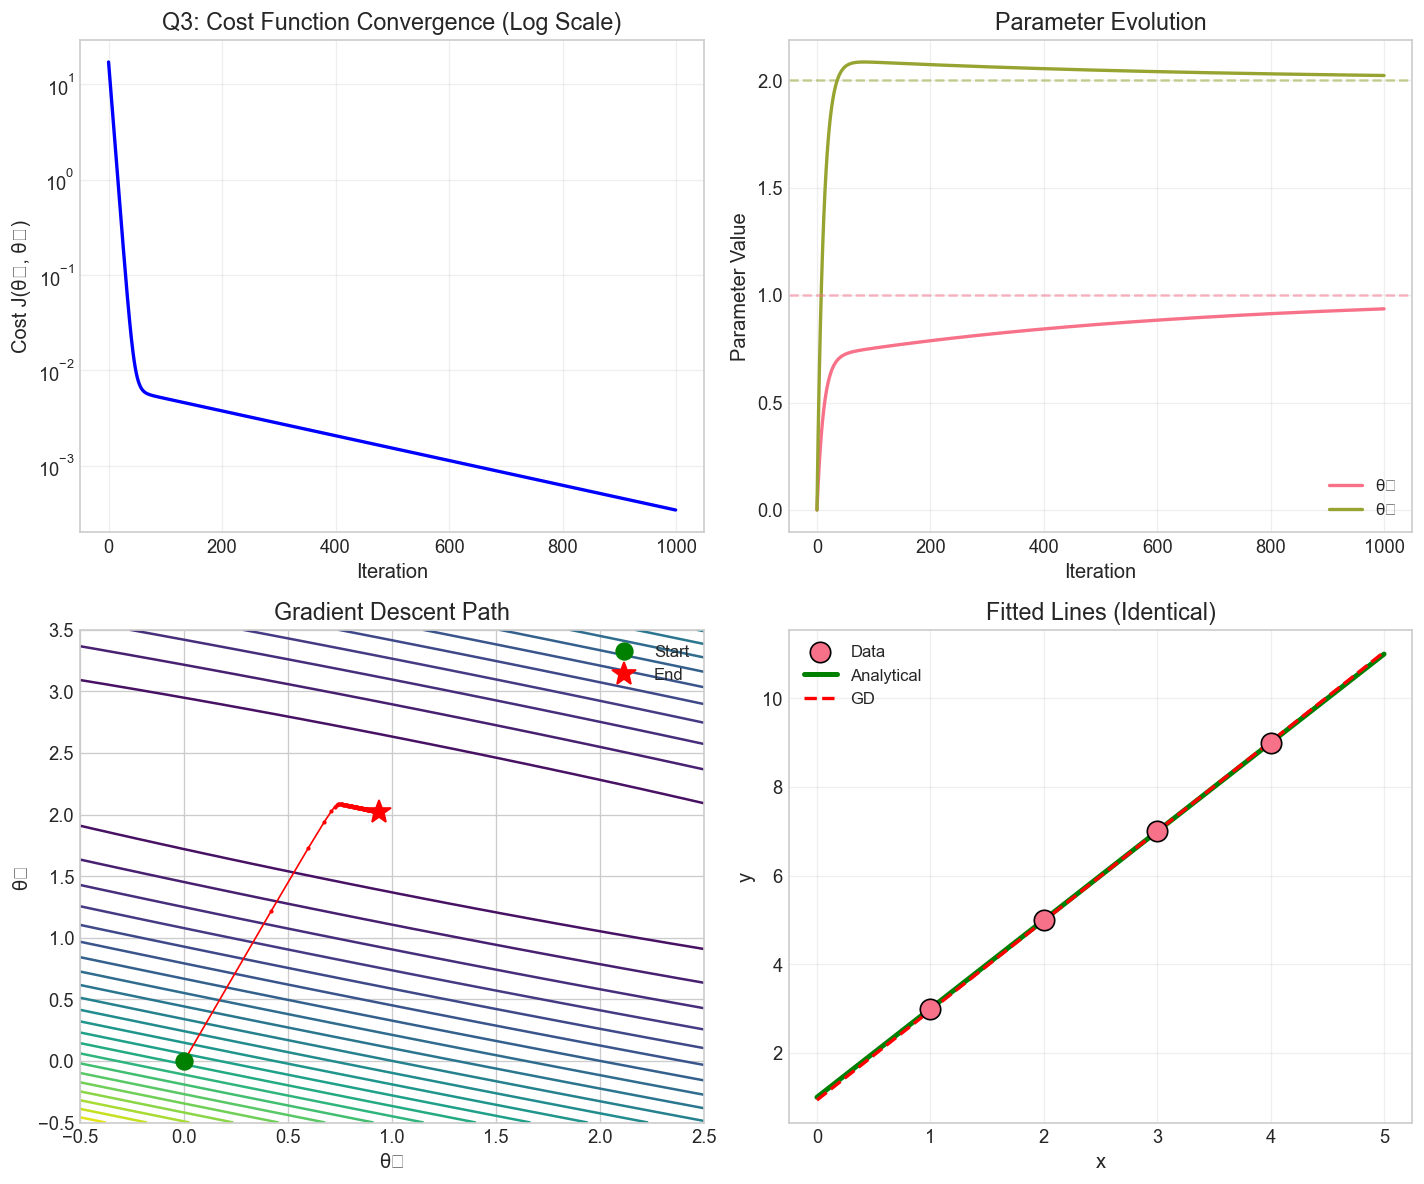

In [17]:
# Visualization for Question 3
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Cost vs iterations
ax1 = axes[0, 0]
ax1.plot(cost_hist, 'b-', linewidth=2)
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Cost J(θ₀, θ₁)')
ax1.set_title('Q3: Cost Function Convergence (Log Scale)')
ax1.set_yscale('log')
ax1.grid(True, alpha=0.3)

# Parameter evolution
ax2 = axes[0, 1]
ax2.plot(t0_hist, label='θ₀', linewidth=2, color=colors[0])
ax2.plot(t1_hist, label='θ₁', linewidth=2, color=colors[2])
ax2.axhline(y=1, color=colors[0], linestyle='--', alpha=0.5)
ax2.axhline(y=2, color=colors[2], linestyle='--', alpha=0.5)
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Parameter Value')
ax2.set_title('Parameter Evolution')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Contour plot with path
ax3 = axes[1, 0]
t0_range = np.linspace(-0.5, 2.5, 100)
t1_range = np.linspace(-0.5, 3.5, 100)
T0, T1 = np.meshgrid(t0_range, t1_range)
Z = np.zeros_like(T0)
for i in range(T0.shape[0]):
    for j in range(T0.shape[1]):
        Z[i, j] = cost_function(T0[i, j], T1[i, j], x3, y3)
contour = ax3.contour(T0, T1, Z, levels=30, cmap='viridis')
ax3.plot(t0_hist[::10], t1_hist[::10], 'r.-', markersize=3, linewidth=1)
ax3.plot(t0_hist[0], t1_hist[0], 'go', markersize=10, label='Start')
ax3.plot(t0_hist[-1], t1_hist[-1], 'r*', markersize=15, label='End')
ax3.set_xlabel('θ₀')
ax3.set_ylabel('θ₁')
ax3.set_title('Gradient Descent Path')
ax3.legend()

# Final fit
ax4 = axes[1, 1]
ax4.scatter(x3, y3, s=150, c=colors[0], label='Data', zorder=5, edgecolors='black')
x_plot = np.linspace(0, 5, 100)
ax4.plot(x_plot, theta_analytical[0] + theta_analytical[1]*x_plot, 'g-', linewidth=3, label='Analytical')
ax4.plot(x_plot, theta0_gd + theta1_gd*x_plot, 'r--', linewidth=2, label='GD')
ax4.set_xlabel('x')
ax4.set_ylabel('y')
ax4.set_title('Fitted Lines (Identical)')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
#plt.savefig('q3_gradient_descent.png', dpi=150, bbox_inches='tight')
plt.show()

---
# Question 4: Brute Force Optimization 

## Problem Statement

Consider the modified Rosenbrock function:

$$J(\theta_1, \theta_2) = (\theta_1 - 2)^2 + 10(\theta_2 - \theta_1^2)^2$$

Find the minimum using brute force grid search.

## Theoretical Background

### Grid Search Algorithm

1. Define parameter ranges: $\theta_1 \in [-2, 4]$, $\theta_2 \in [-1, 5]$
2. Create a grid with step size $\Delta = 0.1$
3. Evaluate $J(\theta_1, \theta_2)$ at every grid point
4. Return the point with minimum cost

### True Minimum

Setting $\nabla J = 0$, the minimum is at $\theta_1 = 2, \theta_2 = 4$ with $J = 0$.

### When to Use Brute Force

- Low-dimensional problems (1-3 parameters)
- Non-differentiable or discontinuous functions
- When global optimum is critical (GD may find local minima)
- Discrete parameter spaces

---

In [18]:
def rosenbrock_modified(theta1, theta2):
    """Modified Rosenbrock function"""
    return (theta1 - 2)**2 + 10*(theta2 - theta1**2)**2

# Grid search
theta1_range = np.arange(-2, 4.1, 0.1)
theta2_range = np.arange(-1, 5.1, 0.1)

start = time.time()
best_t1, best_t2, best_cost = None, None, np.inf
T1_grid, T2_grid = np.meshgrid(theta1_range, theta2_range)
Z_grid = rosenbrock_modified(T1_grid, T2_grid)

for t1 in theta1_range:
    for t2 in theta2_range:
        cost = rosenbrock_modified(t1, t2)
        if cost < best_cost:
            best_cost, best_t1, best_t2 = cost, t1, t2

grid_time = time.time() - start

print("Question 4: Brute Force Optimization")
print("="*50)
print(f"Grid: {len(theta1_range)}×{len(theta2_range)} = {len(theta1_range)*len(theta2_range)} points")
print(f"\nResult: θ₁ = {best_t1:.1f}, θ₂ = {best_t2:.1f}")
print(f"Cost: J = {best_cost:.6f}")
print(f"Time: {grid_time*1000:.2f} ms")
print(f"\nTrue minimum: θ₁ = 2, θ₂ = 4, J = 0")

Question 4: Brute Force Optimization
Grid: 61×61 = 3721 points

Result: θ₁ = 2.0, θ₂ = 4.0
Cost: J = 0.000000
Time: 1.83 ms

True minimum: θ₁ = 2, θ₂ = 4, J = 0


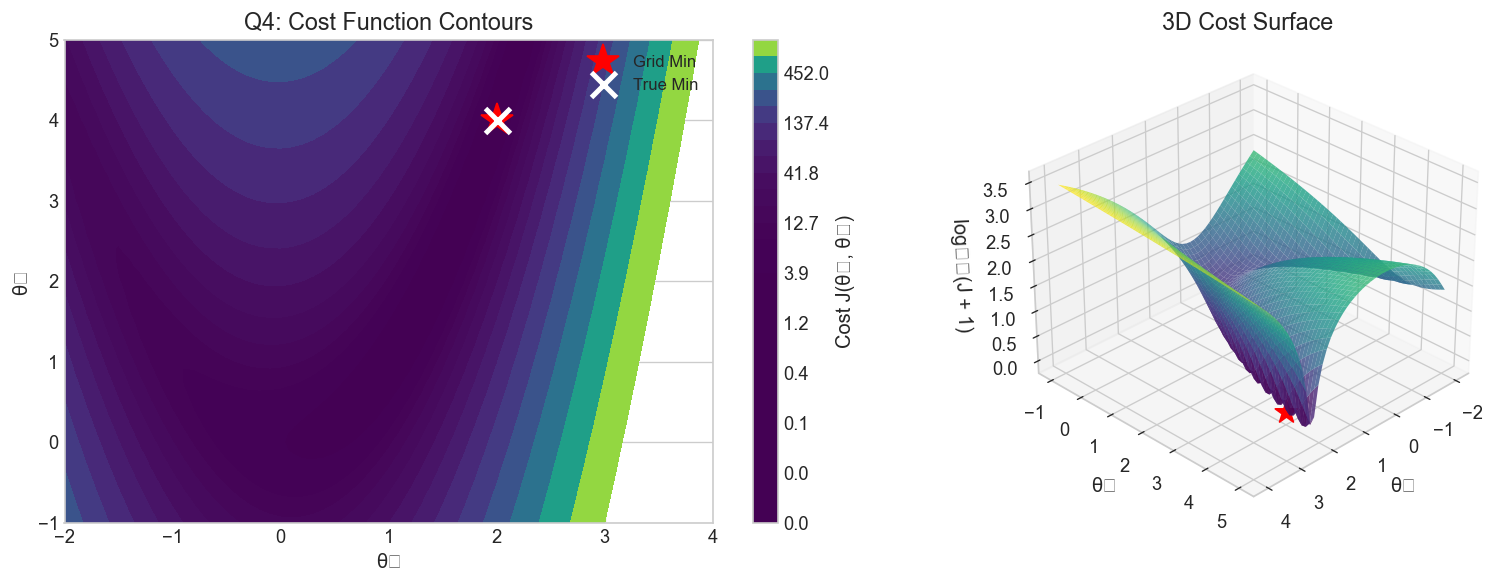

In [19]:
# Visualization for Question 4
fig = plt.figure(figsize=(14, 5))

ax1 = fig.add_subplot(121)
levels = np.logspace(-2, 3, 30)
contour = ax1.contourf(T1_grid, T2_grid, Z_grid, levels=levels, cmap='viridis')
plt.colorbar(contour, ax=ax1, label='Cost J(θ₁, θ₂)')
ax1.plot(best_t1, best_t2, 'r*', markersize=20, label=f'Grid Min')
ax1.plot(2, 4, 'wx', markersize=15, mew=3, label='True Min')
ax1.set_xlabel('θ₁')
ax1.set_ylabel('θ₂')
ax1.set_title('Q4: Cost Function Contours')
ax1.legend()

ax2 = fig.add_subplot(122, projection='3d')
t1_fine = np.linspace(-2, 4, 50)
t2_fine = np.linspace(-1, 5, 50)
T1_fine, T2_fine = np.meshgrid(t1_fine, t2_fine)
Z_fine = rosenbrock_modified(T1_fine, T2_fine)
ax2.plot_surface(T1_fine, T2_fine, np.log10(Z_fine + 1), cmap='viridis', alpha=0.8)
ax2.scatter([best_t1], [best_t2], [np.log10(best_cost + 1)], c='red', s=200, marker='*')
ax2.set_xlabel('θ₁')
ax2.set_ylabel('θ₂')
ax2.set_zlabel('log₁₀(J + 1)')
ax2.set_title('3D Cost Surface')
ax2.view_init(elev=30, azim=45)

plt.tight_layout()
#plt.savefig('q4_brute_force.png', dpi=150, bbox_inches='tight')
plt.show()

---
# Question 5: Non-linear Least Squares 

## Problem Statement

An environmental engineer is modeling Biochemical Oxygen Demand (BOD) in a water treatment study:

| Time (days) | BOD (mg/L) |
|-------------|------------|
| 1 | 10.6 |
| 2 | 16.0 |
| 3 | 18.8 |
| 4 | 20.9 |
| 5 | 22.2 |
| 7 | 23.8 |

## The BOD Model

$$y = \theta_1(1 - e^{-\theta_2 x})$$

where:
- $\theta_1$ = Ultimate BOD (asymptotic maximum, mg/L)
- $\theta_2$ = Deoxygenation rate constant (/day)

## Why Normal Equations Don't Apply

This model is **nonlinear in the parameters**:

1. $\theta_2$ appears in the exponent: $e^{-\theta_2 x}$
2. $\theta_1$ multiplies a term containing $\theta_2$
3. Cannot write as $\mathbf{y} = \mathbf{X}\boldsymbol{\theta}$

**Solution:** Use iterative optimization (scipy.optimize)

---

In [20]:
# Question 5 Data
x5 = np.array([1, 2, 3, 4, 5, 7])
y5 = np.array([10.6, 16.0, 18.8, 20.9, 22.2, 23.8])

def bod_model(x, theta1, theta2):
    return theta1 * (1 - np.exp(-theta2 * x))

def bod_cost(theta, x, y):
    return np.sum((y - bod_model(x, theta[0], theta[1]))**2)

# Optimize
theta_init = [25, 0.5]
result = minimize(bod_cost, theta_init, args=(x5, y5), method='Nelder-Mead')
popt, pcov = curve_fit(bod_model, x5, y5, p0=theta_init)

print("Question 5: Non-linear Least Squares (BOD Model)")
print("="*50)
print(f"\nOptimized Parameters:")
print(f"  θ₁ = {popt[0]:.4f} mg/L (Ultimate BOD)")
print(f"  θ₂ = {popt[1]:.4f} /day (Decay rate)")
print(f"\nHalf-saturation time: t₁/₂ = ln(2)/θ₂ = {np.log(2)/popt[1]:.2f} days")

# Validation
y5_pred = bod_model(x5, popt[0], popt[1])
R2_5 = 1 - np.sum((y5 - y5_pred)**2)/np.sum((y5 - np.mean(y5))**2)
print(f"\nR² = {R2_5:.6f}")

Question 5: Non-linear Least Squares (BOD Model)

Optimized Parameters:
  θ₁ = 23.8393 mg/L (Ultimate BOD)
  θ₂ = 0.5499 /day (Decay rate)

Half-saturation time: t₁/₂ = ln(2)/θ₂ = 1.26 days

R² = 0.993037


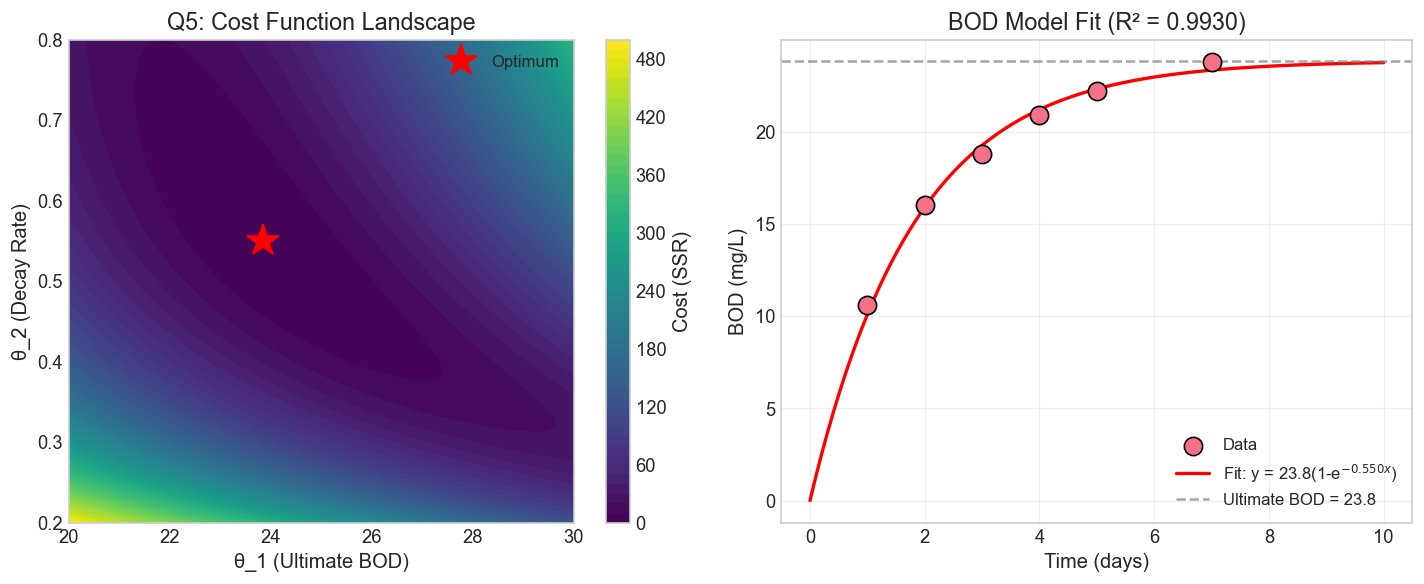

In [21]:
# Visualization for Question 5
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Cost landscape
ax1 = axes[0]
t1_r = np.linspace(20, 30, 80)
t2_r = np.linspace(0.2, 0.8, 80)
T1_5, T2_5 = np.meshgrid(t1_r, t2_r)
Z5 = np.zeros_like(T1_5)
for i in range(T1_5.shape[0]):
    for j in range(T1_5.shape[1]):
        Z5[i,j] = bod_cost([T1_5[i,j], T2_5[i,j]], x5, y5)
contour = ax1.contourf(T1_5, T2_5, Z5, levels=50, cmap='viridis')
plt.colorbar(contour, ax=ax1, label='Cost (SSR)')
ax1.plot(popt[0], popt[1], 'r*', markersize=20, label='Optimum')
ax1.set_xlabel('θ_1 (Ultimate BOD)')
ax1.set_ylabel('θ_2 (Decay Rate)')
ax1.set_title('Q5: Cost Function Landscape')
ax1.legend()

# Model fit
ax2 = axes[1]
ax2.scatter(x5, y5, s=120, c=colors[0], label='Data', zorder=5, edgecolors='black')
x_fine = np.linspace(0, 10, 100)
ax2.plot(x_fine, bod_model(x_fine, popt[0], popt[1]), 'r-', linewidth=2, 
         label=f'Fit: y = {popt[0]:.1f}(1-e$^{{-{popt[1]:.3f}x}}$)')
ax2.axhline(y=popt[0], color='gray', linestyle='--', alpha=0.7, label=f'Ultimate BOD = {popt[0]:.1f}')
ax2.set_xlabel('Time (days)')
ax2.set_ylabel('BOD (mg/L)')
ax2.set_title(f'BOD Model Fit (R² = {R2_5:.4f})')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
#plt.savefig('q5_bod_model.png', dpi=150, bbox_inches='tight')
plt.show()

---
# Question 6: Scaling Effects and Numerical Issues 

## Problem Statement

Temperature measurements over time:

| Time (seconds) | Temperature (K) |
|----------------|----------------|
| 3600 | 298.2 |
| 7200 | 423.7 |
| 10800 | 548.1 |
| 14400 | 671.8 |
| 18000 | 798.5 |

## Theoretical Background

### The Scaling Problem

When features have vastly different scales (here: $x \sim 10^4$, $y \sim 10^2$):

1. **Condition Number:** $\kappa(\mathbf{X}^T\mathbf{X})$ becomes very large
2. **Gradient Descent:** Different features have vastly different gradient magnitudes
3. **Learning Rate:** Must be tiny to prevent divergence, causing slow convergence

### Standardization

Transform features to zero mean, unit variance:

$$x_{scaled} = \frac{x - \mu_x}{\sigma_x}, \quad y_{scaled} = \frac{y - \mu_y}{\sigma_y}$$

After fitting on scaled data, convert parameters back:

$$\theta_1 = \theta_1' \cdot \frac{\sigma_y}{\sigma_x}, \quad \theta_0 = \mu_y - \theta_1 \cdot \mu_x$$

---

In [22]:
# Question 6 Data
x6 = np.array([3600, 7200, 10800, 14400, 18000])
y6 = np.array([298.2, 423.7, 548.1, 671.8, 798.5])
n6 = len(x6)

# Original fit
X6_orig = np.column_stack([np.ones(n6), x6])
theta6_orig = np.linalg.solve(X6_orig.T @ X6_orig, X6_orig.T @ y6)

# Scaled fit
x6_mean, x6_std = np.mean(x6), np.std(x6)
y6_mean, y6_std = np.mean(y6), np.std(y6)
x6_scaled = (x6 - x6_mean) / x6_std
y6_scaled = (y6 - y6_mean) / y6_std
X6_scaled = np.column_stack([np.ones(n6), x6_scaled])
theta6_scaled = np.linalg.solve(X6_scaled.T @ X6_scaled, X6_scaled.T @ y6_scaled)

# Condition numbers
cond_orig = np.linalg.cond(X6_orig.T @ X6_orig)
cond_scaled = np.linalg.cond(X6_scaled.T @ X6_scaled)

print("Question 6: Scaling Effects")
print("="*50)
print(f"\nCondition Numbers:")
print(f"  Original: {cond_orig:.2e}")
print(f"  Scaled:   {cond_scaled:.2e}")
print(f"  Improvement: {cond_orig/cond_scaled:.0f}x better")

print(f"\nGradient Descent Requirements:")
print(f"  Original: needs α < 10⁻⁹ (very slow)")
print(f"  Scaled:   can use α = 0.1-0.5 (fast)")

Question 6: Scaling Effects

Condition Numbers:
  Original: 7.84e+08
  Scaled:   1.00e+00
  Improvement: 784080009x better

Gradient Descent Requirements:
  Original: needs α < 10⁻⁹ (very slow)
  Scaled:   can use α = 0.1-0.5 (fast)


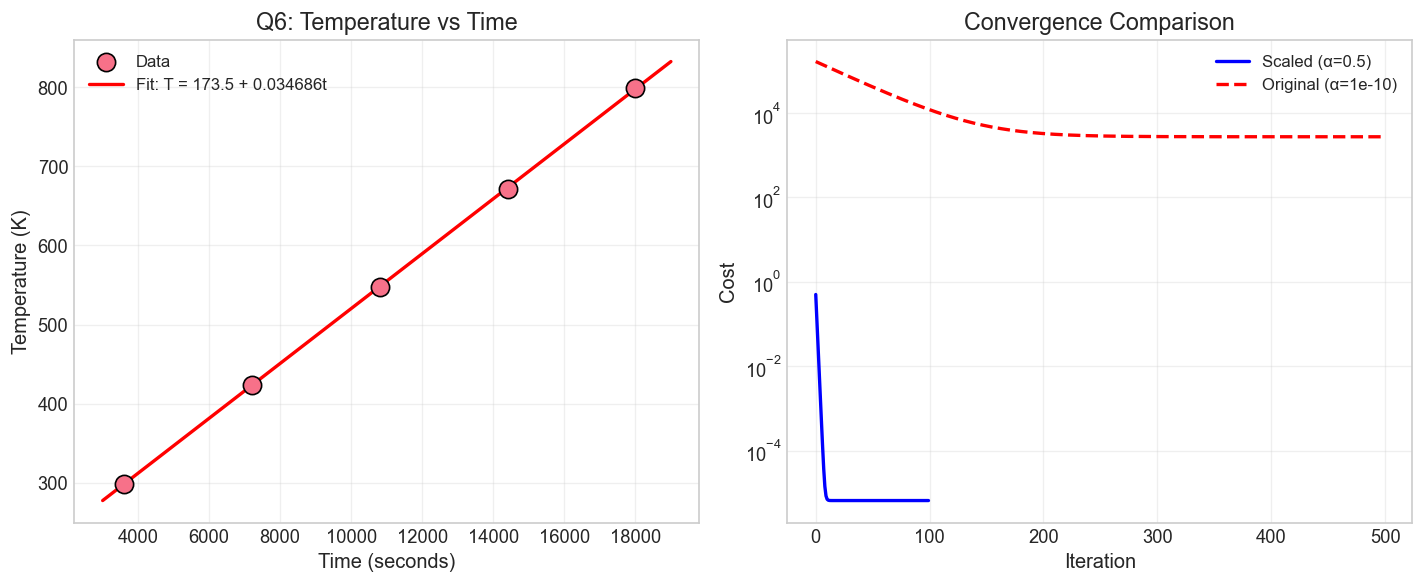

In [23]:
# Visualization for Question 6
def gd_linear(X, y, alpha, iters):
    m = len(y)
    theta = np.zeros(X.shape[1])
    history = []
    for _ in range(iters):
        pred = X @ theta
        err = pred - y
        theta = theta - alpha * (1/m) * X.T @ err
        cost = np.sum(err**2) / (2*m)
        if np.isnan(cost) or cost > 1e20:
            break
        history.append(cost)
    return theta, history

_, hist_scaled = gd_linear(X6_scaled, y6_scaled, 0.5, 100)
_, hist_orig = gd_linear(X6_orig, y6, 1e-10, 5000)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax1 = axes[0]
ax1.scatter(x6, y6, s=120, c=colors[0], label='Data', zorder=5, edgecolors='black')
x_line = np.linspace(3000, 19000, 100)
ax1.plot(x_line, theta6_orig[0] + theta6_orig[1]*x_line, 'r-', linewidth=2, 
         label=f'Fit: T = {theta6_orig[0]:.1f} + {theta6_orig[1]:.6f}t')
ax1.set_xlabel('Time (seconds)')
ax1.set_ylabel('Temperature (K)')
ax1.set_title('Q6: Temperature vs Time')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.plot(hist_scaled, 'b-', linewidth=2, label='Scaled (α=0.5)')
ax2.plot(hist_orig[:500], 'r--', linewidth=2, label='Original (α=1e-10)')
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Cost')
ax2.set_title('Convergence Comparison')
ax2.legend()
ax2.set_yscale('log')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
#plt.savefig('q6_scaling.png', dpi=150, bbox_inches='tight')
plt.show()

---
# Question 7: Weighted Least Squares 

## Problem Statement

Air quality sensor data with varying measurement precision:

| Hour | PM2.5 (µg/m³) | Std Error σ |
|------|---------------|-------------|
| 6 | 45.2 | 2.1 |
| 9 | 52.8 | 1.5 |
| 12 | 67.3 | 3.2 |
| 15 | 71.5 | 1.8 |
| 18 | 58.9 | 2.5 |
| 21 | 41.7 | 1.2 |

## Theoretical Background

### Heteroscedasticity

When observations have **unequal variances** $\sigma_i^2$, OLS is inefficient.

### Weighted Least Squares

The WLS cost function:

$$J(\boldsymbol{\theta}) = \sum_{i=1}^{n} w_i (y_i - \mathbf{x}_i^T\boldsymbol{\theta})^2$$

where the optimal weights are:

$$w_i = \frac{1}{\sigma_i^2}$$

### WLS Normal Equations

$$\hat{\boldsymbol{\theta}}_{WLS} = (\mathbf{X}^T\mathbf{W}\mathbf{X})^{-1}\mathbf{X}^T\mathbf{W}\mathbf{y}$$

where $\mathbf{W} = \text{diag}(w_1, w_2, ..., w_n)$

### Why $w_i = 1/\sigma_i^2$?

- **MLE derivation:** Maximum Likelihood under heteroscedastic normal errors
- **Gauss-Markov:** WLS with these weights is BLUE (Best Linear Unbiased Estimator)
- **Intuition:** More precise measurements (smaller $\sigma$) get higher weights

---

In [24]:
# Question 7 Data
x7 = np.array([6, 9, 12, 15, 18, 21])
y7 = np.array([45.2, 52.8, 67.3, 71.5, 58.9, 41.7])
sigma7 = np.array([2.1, 1.5, 3.2, 1.8, 2.5, 1.2])
n7 = len(x7)

# Weights
w7 = 1 / sigma7**2
W = np.diag(w7)

# Design matrix
X7 = np.column_stack([np.ones(n7), x7])

# WLS solution
theta_wls = np.linalg.solve(X7.T @ W @ X7, X7.T @ W @ y7)

# OLS for comparison
theta_ols = np.linalg.solve(X7.T @ X7, X7.T @ y7)

print("Question 7: Weighted Least Squares")
print("="*50)
print(f"\nWeights (w = 1/σ²):")
for h, s, w in zip(x7, sigma7, w7):
    print(f"  Hour {h}: σ={s}, w={w:.4f}")

print(f"\n{'Parameter':<12} {'OLS':<15} {'WLS':<15}")
print("-"*42)
print(f"{'θ₀':<12} {theta_ols[0]:<15.4f} {theta_wls[0]:<15.4f}")
print(f"{'θ₁':<12} {theta_ols[1]:<15.4f} {theta_wls[1]:<15.4f}")

Question 7: Weighted Least Squares

Weights (w = 1/σ²):
  Hour 6: σ=2.1, w=0.2268
  Hour 9: σ=1.5, w=0.4444
  Hour 12: σ=3.2, w=0.0977
  Hour 15: σ=1.8, w=0.3086
  Hour 18: σ=2.5, w=0.1600
  Hour 21: σ=1.2, w=0.6944

Parameter    OLS             WLS            
------------------------------------------
θ₀           55.5905         59.9083        
θ₁           0.0476          -0.5240        


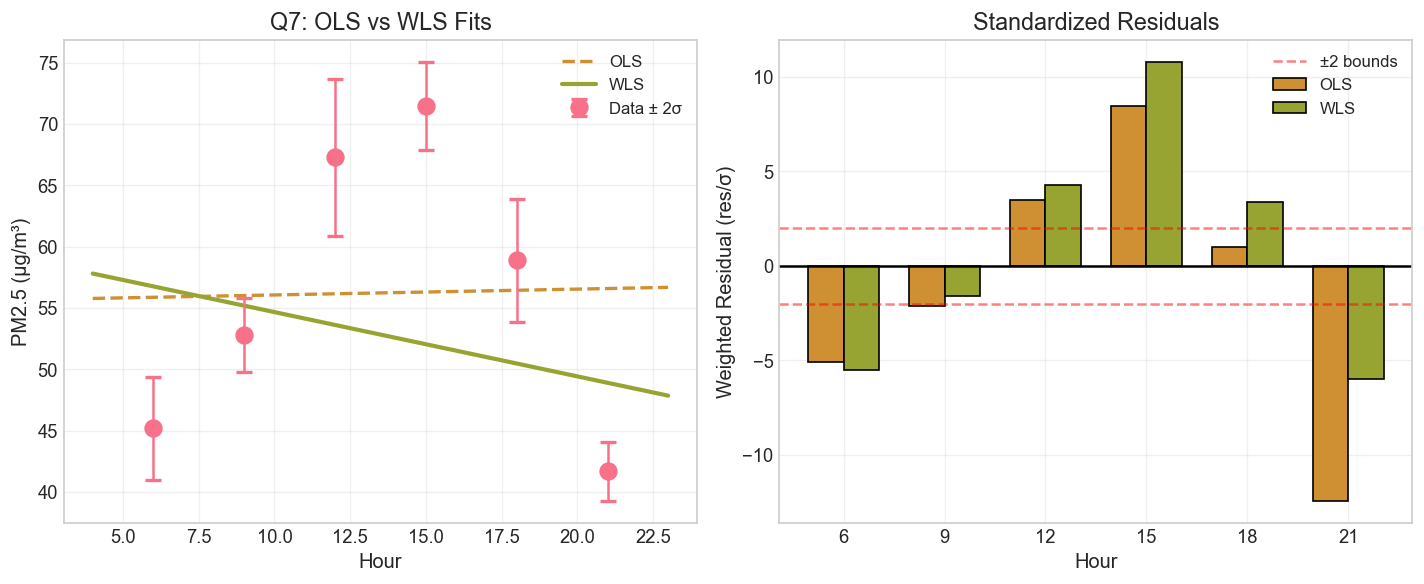

In [25]:
# Visualization for Question 7
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax1 = axes[0]
ax1.errorbar(x7, y7, yerr=2*sigma7, fmt='o', capsize=5, capthick=2, 
             markersize=10, color=colors[0], label='Data ± 2σ', zorder=5)
x_line = np.linspace(4, 23, 100)
ax1.plot(x_line, theta_ols[0] + theta_ols[1]*x_line, '--', color=colors[1], linewidth=2, label='OLS')
ax1.plot(x_line, theta_wls[0] + theta_wls[1]*x_line, '-', color=colors[2], linewidth=2.5, label='WLS')
ax1.set_xlabel('Hour')
ax1.set_ylabel('PM2.5 (µg/m³)')
ax1.set_title('Q7: OLS vs WLS Fits')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Weighted residuals
res_ols = y7 - X7 @ theta_ols
res_wls = y7 - X7 @ theta_wls
wres_ols = res_ols / sigma7
wres_wls = res_wls / sigma7

ax2 = axes[1]
width = 0.35
x_pos = np.arange(n7)
ax2.bar(x_pos - width/2, wres_ols, width, label='OLS', color=colors[1], edgecolor='black')
ax2.bar(x_pos + width/2, wres_wls, width, label='WLS', color=colors[2], edgecolor='black')
ax2.axhline(y=0, color='black')
ax2.axhline(y=2, color='red', linestyle='--', alpha=0.5, label='±2 bounds')
ax2.axhline(y=-2, color='red', linestyle='--', alpha=0.5)
ax2.set_xlabel('Hour')
ax2.set_ylabel('Weighted Residual (res/σ)')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(x7)
ax2.set_title('Standardized Residuals')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
#plt.savefig('q7_weighted_ls.png', dpi=150, bbox_inches='tight')
plt.show()

Observation: The linear model is inappropriate 
- PM2.5 follows a daily cycle (low morning/evening, peak afternoon), not a linear trend
- WLS does what it's supposed to: prioritizes fitting high-precision measurements (Hours 9, 21)
- Better approach: Use a nonlinear model (e.g., quadratic, sinusoidal) to capture the diurnal pattern
- WLS is still valuable: even with a better model, WLS would appropriately weight the varying measurement precisions

---
# Question 8: Comprehensive Implementation 

## Problem Statement

An electric vehicle manufacturer needs to predict battery capacity degradation to:
- Estimate warranty periods
- Schedule maintenance
- Predict end-of-life (typically 80% capacity)

## Data

12 measurements of battery capacity (% of original) vs charge/discharge cycles.

## Degradation Models

### 1. Linear Model
$$\text{Capacity} = \theta_0 + \theta_1 \cdot \text{cycles}$$

### 2. Square Root Model (SEI Layer Growth)
$$\text{Capacity} = \theta_0 + \theta_1 \cdot \sqrt{\text{cycles}}$$

The $\sqrt{\text{cycles}}$ term models Solid Electrolyte Interphase (SEI) layer growth.

### 3. Combined Model
$$\text{Capacity} = \theta_0 + \theta_1 \cdot \sqrt{\text{cycles}} + \theta_2 \cdot \text{cycles}$$

Captures both SEI growth and calendar aging.

## Requirements

1. Implement three solution methods
2. Compare models using R², Adjusted R², RMSE
3. Validate model assumptions
4. Predict end-of-life (when capacity = 80%)

---

In [26]:
# Generate battery data
np.random.seed(42)
cycles = np.array([0, 50, 100, 150, 200, 250, 300, 400, 500, 600, 700, 800])
true_a, true_b = 0.6, 0.0002
capacity = 100 - true_a * np.sqrt(cycles) - true_b * cycles + np.random.normal(0, 0.8, len(cycles))
capacity[0] = 100.0
n8 = len(cycles)

print("Question 8: Battery Degradation Analysis")
print("="*50)
print(f"{'Cycles':<12} {'Capacity (%)':<15}")
print("-"*27)
for c, cap in zip(cycles, capacity):
    print(f"{c:<12} {cap:<15.2f}")

Question 8: Battery Degradation Analysis
Cycles       Capacity (%)   
---------------------------
0            100.00         
50           95.64          
100          94.50          
150          93.84          
200          91.29          
250          90.28          
300          90.81          
400          88.53          
500          86.11          
600          85.62          
700          83.61          
800          82.50          


## Part (b): Three Solution Methods

In [27]:
# Design matrix (linear)
X8 = np.column_stack([np.ones(n8), cycles])

# Method 1: Normal equations
start = time.time()
theta_ne = np.linalg.solve(X8.T @ X8, X8.T @ capacity)
time_ne = time.time() - start

# Method 2: Gradient descent (scaled)
cyc_scaled = (cycles - np.mean(cycles)) / np.std(cycles)
cap_scaled = (capacity - np.mean(capacity)) / np.std(capacity)
X8_scaled = np.column_stack([np.ones(n8), cyc_scaled])

start = time.time()
theta_gd_s, _ = gd_linear(X8_scaled, cap_scaled, 0.1, 1000)
time_gd = time.time() - start
theta1_gd = theta_gd_s[1] * np.std(capacity) / np.std(cycles)
theta0_gd = np.mean(capacity) - theta1_gd * np.mean(cycles)

# Method 3: scipy
start = time.time()
result = minimize(lambda t: np.sum((capacity - X8 @ t)**2), [0, 0], method='BFGS')
time_scipy = time.time() - start

print("Three Solution Methods Comparison:")
print("="*60)
print(f"{'Method':<20} {'θ₀':<12} {'θ₁':<14} {'Time (ms)':<10}")
print("-"*60)
print(f"{'Normal Equations':<20} {theta_ne[0]:<12.4f} {theta_ne[1]:<14.8f} {time_ne*1000:<10.4f}")
print(f"{'Gradient Descent':<20} {theta0_gd:<12.4f} {theta1_gd:<14.8f} {time_gd*1000:<10.4f}")
print(f"{'scipy BFGS':<20} {result.x[0]:<12.4f} {result.x[1]:<14.8f} {time_scipy*1000:<10.4f}")

Three Solution Methods Comparison:
Method               θ₀           θ₁             Time (ms) 
------------------------------------------------------------
Normal Equations     96.7381      -0.01929318    0.1261    
Gradient Descent     96.7381      -0.01929318    5.6348    
scipy BFGS           96.7381      -0.01929320    1.3626    


## Part (c) & (d): Feature Engineering and Model Comparison

In [28]:
SS_tot = np.sum((capacity - np.mean(capacity))**2)

# Linear model
pred_lin = X8 @ theta_ne
R2_lin = 1 - np.sum((capacity - pred_lin)**2)/SS_tot

# Square root model
X8_sqrt = np.column_stack([np.ones(n8), np.sqrt(cycles)])
theta_sqrt = np.linalg.solve(X8_sqrt.T @ X8_sqrt, X8_sqrt.T @ capacity)
pred_sqrt = X8_sqrt @ theta_sqrt
R2_sqrt = 1 - np.sum((capacity - pred_sqrt)**2)/SS_tot

# Combined model
X8_comb = np.column_stack([np.ones(n8), np.sqrt(cycles), cycles])
theta_comb = np.linalg.solve(X8_comb.T @ X8_comb, X8_comb.T @ capacity)
pred_comb = X8_comb @ theta_comb
R2_comb = 1 - np.sum((capacity - pred_comb)**2)/SS_tot

# Adjusted R²
R2_adj_lin = 1 - (1-R2_lin)*(n8-1)/(n8-2)
R2_adj_sqrt = 1 - (1-R2_sqrt)*(n8-1)/(n8-2)
R2_adj_comb = 1 - (1-R2_comb)*(n8-1)/(n8-3)

print("\nModel Comparison:")
print("="*60)
print(f"{'Model':<20} {'R²':<12} {'Adj R²':<12}")
print("-"*45)
print(f"{'Linear (x)':<20} {R2_lin:<12.6f} {R2_adj_lin:<12.6f}")
print(f"{'Square Root (√x)':<20} {R2_sqrt:<12.6f} {R2_adj_sqrt:<12.6f}")
print(f"{'Combined (√x + x)':<20} {R2_comb:<12.6f} {R2_adj_comb:<12.6f}")
print(f"\nBest Model: Combined")
print(f"Capacity = {theta_comb[0]:.2f} + ({theta_comb[1]:.4f})√cycles + ({theta_comb[2]:.6f})×cycles")


Model Comparison:
Model                R²           Adj R²      
---------------------------------------------
Linear (x)           0.937185     0.930904    
Square Root (√x)     0.987212     0.985934    
Combined (√x + x)    0.990177     0.987994    

Best Model: Combined
Capacity = 99.86 + (-0.5051)√cycles + (-0.003818)×cycles


## Part (e): Model Validation and End-of-Life Prediction

In [29]:
# Validation
res_comb = capacity - pred_comb
stat, p_val = shapiro(res_comb)

print("Model Validation:")
print("="*50)
print(f"Shapiro-Wilk test: p = {p_val:.4f} ({'Normal' if p_val > 0.05 else 'Not Normal'})")
print(f"RMSE = {np.sqrt(np.mean(res_comb**2)):.4f}%")

# End-of-life prediction
def eol_eq(x):
    return theta_comb[0] + theta_comb[1]*np.sqrt(x) + theta_comb[2]*x - 80

x_eol = fsolve(eol_eq, 500)[0]
print(f"\nEnd-of-Life Prediction:")
print(f"Battery reaches 80% capacity at ~{x_eol:.0f} cycles")

Model Validation:
Shapiro-Wilk test: p = 0.5015 (Normal)
RMSE = 0.4973%

End-of-Life Prediction:
Battery reaches 80% capacity at ~1006 cycles


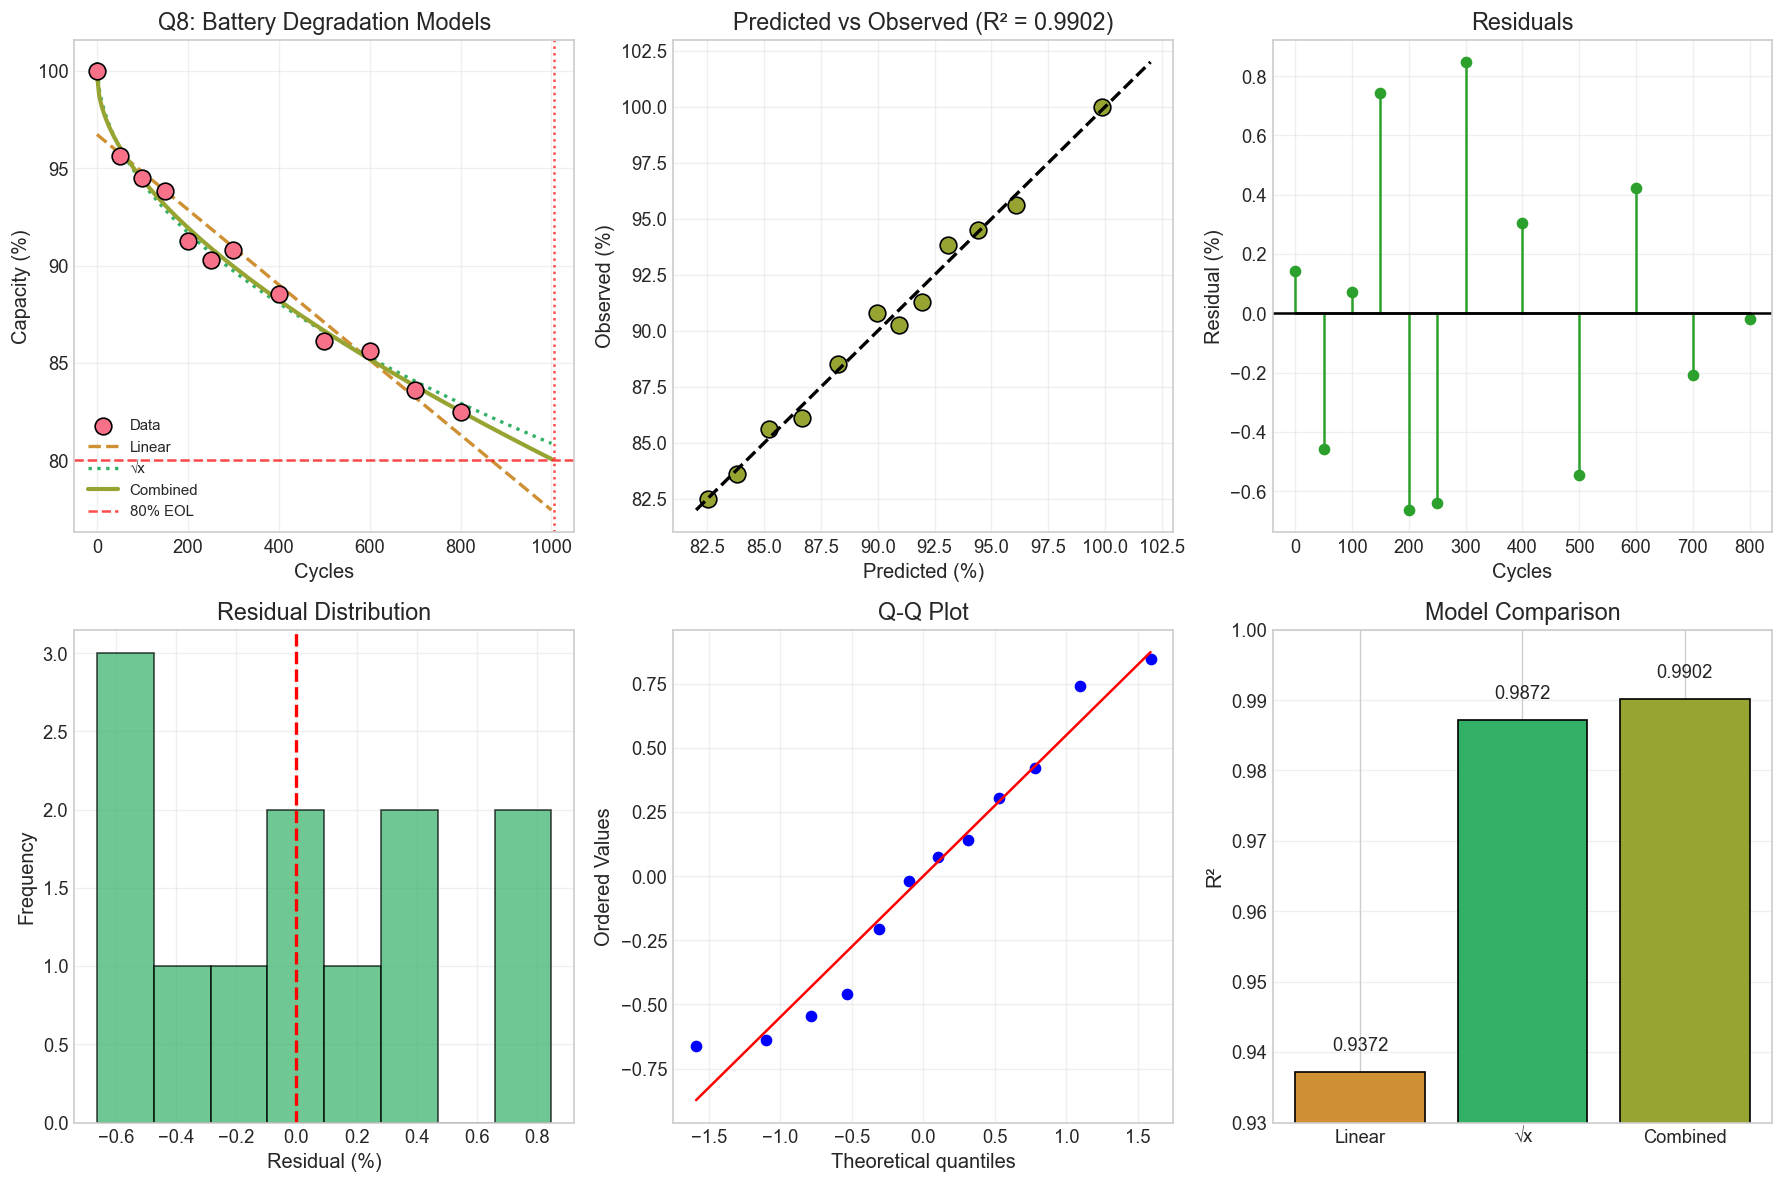

In [30]:
# Final visualization
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Model comparison
ax1 = axes[0, 0]
ax1.scatter(cycles, capacity, s=100, c=colors[0], label='Data', zorder=5, edgecolors='black')
x_fine = np.linspace(0, 1000, 200)
ax1.plot(x_fine, theta_ne[0] + theta_ne[1]*x_fine, '--', color=colors[1], linewidth=2, label='Linear')
ax1.plot(x_fine, theta_sqrt[0] + theta_sqrt[1]*np.sqrt(x_fine), ':', color=colors[3], linewidth=2, label='√x')
ax1.plot(x_fine, theta_comb[0] + theta_comb[1]*np.sqrt(x_fine) + theta_comb[2]*x_fine, '-', 
         color=colors[2], linewidth=2.5, label='Combined')
ax1.axhline(y=80, color='red', linestyle='--', alpha=0.7, label='80% EOL')
ax1.axvline(x=x_eol, color='red', linestyle=':', alpha=0.7)
ax1.set_xlabel('Cycles')
ax1.set_ylabel('Capacity (%)')
ax1.set_title('Q8: Battery Degradation Models')
ax1.legend(loc='lower left', fontsize=9)
ax1.grid(True, alpha=0.3)

# Predicted vs Observed
ax2 = axes[0, 1]
ax2.scatter(pred_comb, capacity, s=100, c=colors[2], edgecolors='black')
ax2.plot([82, 102], [82, 102], 'k--', linewidth=2)
ax2.set_xlabel('Predicted (%)')
ax2.set_ylabel('Observed (%)')
ax2.set_title(f'Predicted vs Observed (R² = {R2_comb:.4f})')
ax2.grid(True, alpha=0.3)

# Residuals
ax3 = axes[0, 2]
ax3.stem(cycles, res_comb, basefmt='k-', linefmt='C2-', markerfmt='C2o')
ax3.axhline(y=0, color='black')
ax3.set_xlabel('Cycles')
ax3.set_ylabel('Residual (%)')
ax3.set_title('Residuals')
ax3.grid(True, alpha=0.3)

# Histogram
ax4 = axes[1, 0]
ax4.hist(res_comb, bins=8, edgecolor='black', alpha=0.7, color=colors[3])
ax4.axvline(x=0, color='red', linestyle='--', linewidth=2)
ax4.set_xlabel('Residual (%)')
ax4.set_ylabel('Frequency')
ax4.set_title('Residual Distribution')
ax4.grid(True, alpha=0.3)

# Q-Q plot
ax5 = axes[1, 1]
stats.probplot(res_comb, plot=ax5)
ax5.set_title('Q-Q Plot')
ax5.grid(True, alpha=0.3)

# Model comparison bars
ax6 = axes[1, 2]
models = ['Linear', '√x', 'Combined']
r2_vals = [R2_lin, R2_sqrt, R2_comb]
bars = ax6.bar(models, r2_vals, color=[colors[1], colors[3], colors[2]], edgecolor='black')
ax6.set_ylabel('R²')
ax6.set_title('Model Comparison')
ax6.set_ylim(0.93, 1.0)
for bar, val in zip(bars, r2_vals):
    ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003, f'{val:.4f}', ha='center')
ax6.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
#plt.savefig('q8_comprehensive.png', dpi=150, bbox_inches='tight')
plt.show()

---
# Summary

## Key Takeaways

| Question | Topic | Key Concept |
|----------|-------|-------------|
| 1 | Linear Regression | Normal equations: $\hat{\theta} = (X^TX)^{-1}X^Ty$ |
| 2 | Polynomial Regression | Linear in parameters despite $x^2$ term |
| 3 | Gradient Descent | Update: $\theta := \theta - \alpha \nabla J$ |
| 4 | Brute Force | Grid search for global minimum |
| 5 | Nonlinear LS | Iterative optimization required |
| 6 | Scaling | Condition number affects convergence |
| 7 | Weighted LS | Weights $w_i = 1/\sigma_i^2$ for heteroscedasticity |
| 8 | Comprehensive | Model selection, validation, prediction |

## When to Use Each Method

- **Normal Equations:** Small-medium data, exact solution needed
- **Gradient Descent:** Large datasets, streaming data, online learning
- **scipy.optimize:** Complex constraints, non-quadratic objectives
- **Grid Search:** Low dimensions, global optimum critical

---
*Assignment Complete*